In [1]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import cv2 as cv

#Impoting the image
img = cv.imread('heroine.jpg')

#Changing the image to gray scale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

#Initialize SIFT detector
sift = cv.SIFT_create()

#Detecting key points of the image
kp = sift.detect(gray, None)

#Drawing the keypoints on the image
img = cv.drawKeypoints(gray, kp, img)

#DIsplay image with keypoints
cv.imshow('SIFT Keypoints', img)
cv.waitKey(0)
cv.imwrite('sift_keypoints.jpg', img)


True

In [3]:
import numpy as np

#Create a mask initaialise with zero
mask = np.zeros(gray.shape, dtype=np.uint8)

#Define ROI coordinates
x_start,y_start = 290,170
x_end,y_end = 456,368

#Set the ROI area in the mask to 255
mask[y_start:y_end, x_start:x_end] = 255

#Initialize SIFT detector
sift = cv.SIFT_create()

#Detect keypoints using mask
kp = sift.detect(gray,mask)

# Draw keypoints on the image
img_with_kp = cv.drawKeypoints(img, kp, None)

# Highlight the ROI with a rectangle (in red for visibility)
cv.rectangle(img_with_kp, (x_start, y_start), (x_end, y_end), (0, 0, 255), 2) 

# Display the image with keypoints and ROI
cv.imshow('SIFT Keypoints with ROI', img_with_kp)
cv.waitKey(0)

-1

######
 it computes 128-dimensional descriptor vectors for the SIFT keypoints detected earlier, encoding local image gradient patterns around each keypoint in a rotation- and scale-invariant way.

In [5]:
kp, des = sift.detectAndCompute(gray, mask)
if des is not None:
    print(f"Found {len(kp)} keypoints with descriptors shape: {des.shape}")
else:
    print("No keypoints or descriptors found—try enlarging ROI or reducing mask constraints.")

No keypoints or descriptors found—try enlarging ROI or reducing mask constraints.


In [2]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 2.7 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.1 MB 3.2 MB/s eta 0:00:03
   --------- ------------------------------ 1.8/8.1 MB 3.1 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.1 MB 3.2 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.1 MB 3.2 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 3.3 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 3.4 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.1 MB 3.4 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.1 MB 3.4 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 3.5 MB/s eta 0:00:01
   -------------------------------


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Found 4332 keypoints
Descriptors shape: (4332, 128)


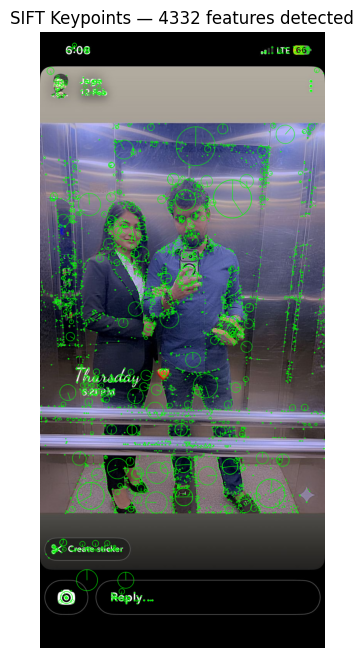

Image with keypoints saved as: sift_keypoints_heroine.jpg


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────
# Load your image (change filename if needed)
# ────────────────────────────────────────────────
img_path = 'test1.jpg'  # Change this to your image path
img = cv2.imread(img_path)

if img is None:
    print(f"Error: Could not load image at '{img_path}'. Check the file path and name.")
    exit()

# Convert to grayscale (SIFT works on grayscale)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


# Initialize SIFT detector

sift = cv2.SIFT_create(
    nfeatures=0,           # 0 = unlimited (default is 0 anyway)
    nOctaveLayers=3,
    contrastThreshold=0.04,
    edgeThreshold=10,
    sigma=1.6
)

# Detect keypoints and compute descriptors
kp, des = sift.detectAndCompute(gray, None)

if kp is None or len(kp) == 0:
    print("No keypoints were detected. The image might be too smooth/blurry — try a different image.")
    exit()

print(f"Found {len(kp)} keypoints")
if des is not None:
    print(f"Descriptors shape: {des.shape}")
else:
    print("Descriptors could not be computed (very unusual with SIFT)")

# ────────────────────────────────────────────────
# Draw keypoints on the original image
# ────────────────────────────────────────────────
# Rich keypoints = show orientation + scale as circles with lines
img_with_kp = cv2.drawKeypoints(
    img, 
    kp, 
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    color=(0, 255, 0)   # green
)

# ────────────────────────────────────────────────
# Show the result — choose one or both methods
# ────────────────────────────────────────────────

# Option 1: Using matplotlib (recommended for Jupyter/notebooks — correct colors)
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_with_kp, cv2.COLOR_BGR2RGB))
plt.title(f'SIFT Keypoints — {len(kp)} features detected')
plt.axis('off')
plt.show()

# Option 2: Using OpenCV window (good for standalone .py scripts)
# cv2.imshow('SIFT Keypoints', img_with_kp)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

# Save the result
output_path = 'sift_keypoints_heroine.jpg'
cv2.imwrite(output_path, img_with_kp)
print(f"Image with keypoints saved as: {output_path}")

In [1]:
pip install torch torchvision

  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-win_amd64.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/113.8 MB 3.1 MB/s eta 0:00:37
   ---------------------------------------- 0.8/113.8 MB 3.2 MB/s eta 0:00:36
    --------------------------------------- 1.6/113.8 MB 2.8 MB/s eta 0:00:41
    --------------------------------------- 2.1/113.8 MB 2.6 MB/s eta 0:00:44
    --------------------------------------- 2.6/113.8 MB 2.7 MB/s eta 0:00:42
   - -------------------------------------- 3.1/113.8 MB 2.6 MB/s eta 0:00:43
   - -------------------------------------- 3.4/113.8 MB 


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image

# -----------------------------
# Load image with OpenCV
# -----------------------------
img_path = 'test1.jpg'  # Change this to your image path
img_bgr = cv2.imread(img_path)
if img_bgr is None:
    print(f"Error: Could not load image at '{img_path}'")
    raise SystemExit

# Keep a copy for visualization
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# -----------------------------
# Preprocess for ResNet
# -----------------------------
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet mean
        std=[0.229, 0.224, 0.225]     # ImageNet std
    )
])

input_tensor = preprocess(img_rgb)          # C x H x W
input_batch = input_tensor.unsqueeze(0)     # 1 x C x H x W

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_batch = input_batch.to(device)

# -----------------------------
# Load pretrained CNN
# -----------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model = model.to(device)
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [3]:
# Choose the target convolutional layer for Grad-CAM.
# For ResNet50, a common choice is layer4 (the last conv block).
target_layer = model.layer4[-1]

activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output.detach()

def backward_hook(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0].detach()

# Register hooks
forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_backward_hook(backward_hook)


In [4]:
# Forward pass
output = model(input_batch)          # shape: [1, 1000] for ImageNet

# Pick the top predicted class as target
pred_class = output.argmax(dim=1).item()

# Backward pass for Grad-CAM
model.zero_grad()
class_score = output[0, pred_class]
class_score.backward()

# Now 'activations' and 'gradients' are filled by the hooks
# activations: [1, C, H', W'], gradients: [1, C, H', W']

# 1. Global average pool gradients over spatial dims to get weights
weights = gradients.mean(dim=(2, 3), keepdim=True)  # [1, C, 1, 1]

# 2. Weight the activations and sum over channels
grad_cam = (weights * activations).sum(dim=1, keepdim=True)  # [1, 1, H', W']

# 3. ReLU
grad_cam = F.relu(grad_cam)

# 4. Normalize to [0, 1]
grad_cam = grad_cam.squeeze().cpu().numpy()
grad_cam -= grad_cam.min()
if grad_cam.max() > 0:
    grad_cam /= grad_cam.max()


c:\Users\Gattupalli Saketh\OneDrive\Desktop\XAI\myenv\Lib\site-packages\torch\nn\modules\module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


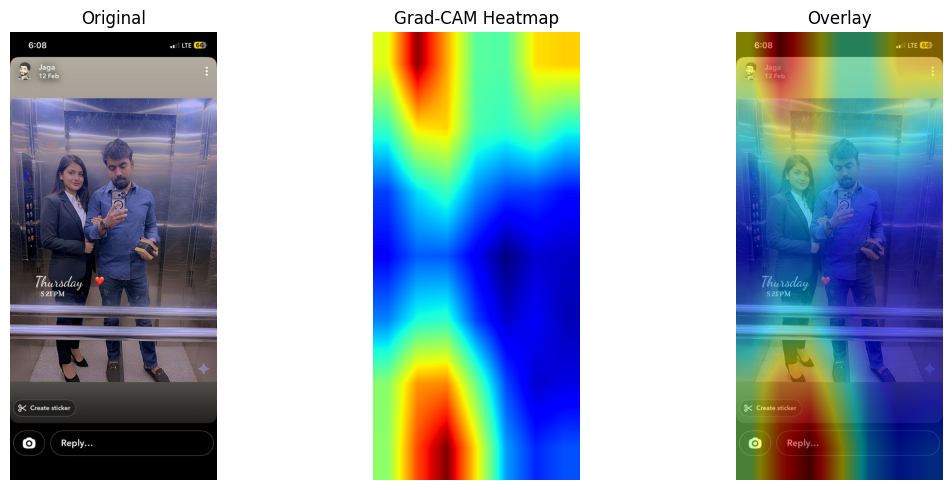

Saved Grad-CAM overlay as gradcam_heroine_overlay.jpg


In [5]:
# Resize heatmap to original size
heatmap = cv2.resize(grad_cam, (img_rgb.shape[1], img_rgb.shape[0]))

# Convert to color heatmap
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

# Overlay on original image
alpha = 0.5  # transparency factor
overlay = np.uint8(alpha * heatmap_color + (1 - alpha) * img_rgb)

# Show and save
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.axis('off')
plt.imshow(img_rgb)

plt.subplot(1, 3, 2)
plt.title("Grad-CAM Heatmap")
plt.axis('off')
plt.imshow(heatmap, cmap='jet')

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.axis('off')
plt.imshow(overlay)

plt.tight_layout()
plt.show()

cv2.imwrite('gradcam_heroine_overlay.jpg',
            cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
print("Saved Grad-CAM overlay as gradcam_heroine_overlay.jpg")


In [2]:
pip install scikit-image

   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.9 MB 4.6 MB/s eta 0:00:03
   ------ --------------------------------- 1.8/11.9 MB 4.9 MB/s eta 0:00:03
   -------- ------------------------------- 2.6/11.9 MB 4.5 MB/s eta 0:00:03
   ------------- -------------------------- 3.9/11.9 MB 5.4 MB/s eta 0:00:02
   --------------- ------------------------ 4.7/11.9 MB 5.0 MB/s eta 0:00:02
   -------------------- ------------------- 6.0/11.9 MB 5.1 MB/s eta 0:00:02
   ----------------------- ---------------- 7.1/11.9 MB 5.2 MB/s eta 0:00:01
   --------------------------- ------------ 8.1/11.9 MB 5.2 MB/s eta 0:00:01
   ------------------------------ --------- 9.2/11.9 MB 5.2 MB/s eta 0:00:01
   ------------------------------- -------- 9.4/11.9 MB 5.0 MB/s eta 0:00:01
   ---------------------------------- ----- 10.2/11.9 MB 4.7 MB/s eta 0:00:01
   ------------------------------------ --- 11.0/11.9 MB 4.6 MB/s eta 0:00:01
   -


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.models import resnet50
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize

def generate_masks(N,H,W,s = 8,p=0.5,seed =None):
    if seed is not None:
        np.random.seed(seed)

    cell_size = np.ceil(np.array([H,W])/s).astype(int)
    up_size = (cell_size[0]*s,cell_size[1]*s)
    num_tall_cells = H - up_size[0]
    num_wide_cells = W - up_size[1]
    masks = np.random.binomial(1,p,(N,s,s))
    masks = np.kron(masks,np.ones((cell_size[0],cell_size[1])))
    masks = masks[:,:up_size[0],:up_size[1]]
    pad0 = np.tile(masks[:,-1:,:],(1,num_tall_cells,1))
    pad1 = np.tile(masks[:,:,-1:],(1,1,num_wide_cells))
    masks = np.concatenate([masks,pad0,pad1],axis = 2)
    masks = masks[:,:H,:W]
    return torch.from_numpy(masks).float()

def rise_saliency(model,img_tensor,target_class=None,N=4000,s=8,p=0.5,batch_size = 100):
    model.eval()
    device = img_tensor.device
    H,W = img_tensor.shape[-2:]
    masks = generate_masks(N,H,W,s,p)
    masks = masks.to(device).unsqueeze(1)
    saliency = torch.zeros((1,1,H,W),device=device)
    img_expanded = img_tensor.expand_as(masks)

    with torch.no_grad():
        for i in range(0, N, batch_size):
            batch_masks = masks[i:i+batch_size]
            batch_imgs = img_expanded * batch_masks
            logits = model(batch_imgs)
            if target_class is None:
                probs = F.softmax(logits, dim=1)
                scores = probs.max(1)[0]  # max prob
            else:
                scores = logits[:, target_class]
            batch_contrib = scores.view(-1, 1, 1, 1) * batch_masks
            saliency += batch_contrib.sum(dim=0)
    
    saliency /= (N * p)
    saliency = F.relu(saliency)  # Non-negative
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    return saliency.squeeze().cpu().numpy()

# Load image and model
img_path = 'heroine.jpg'  # Replace with your image path
img = Image.open(img_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
img_tensor = transform(img).unsqueeze(0)  # (1, 3, 224, 224)

model = resnet50(pretrained=True)
model.eval()


with torch.no_grad():
    logits = model(img_tensor)
    pred_class = logits.argmax(1).item()
    print(f"Predicted class: {pred_class}")

# Compute RISE
saliency = rise_saliency(model, img_tensor, target_class=pred_class, N=4000, s=8, p=0.5)

# Visualize
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(np.array(img))
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(saliency, cmap='jet')
plt.title('RISE Saliency')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(np.array(img))
plt.imshow(saliency, cmap='jet', alpha=0.5)
plt.title('Overlay')
plt.axis('off')
plt.savefig('rise_result.png')
plt.show()





Predicted class: 459


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 224 and the array at index 1 has size 0